In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
"""
A time-series regression project for predicting the next day's maximum temperature
across 49 cities using the previous seven days of temperature data.
The project evaluates Linear Regression performance using R² and MAE metrics.
""";

In [26]:
df = pd.read_csv('datasets/weatherAUS.csv')
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [27]:
df = df.loc[:, ['Location', 'MaxTemp', 'Date']]
df

,Location,MaxTemp,Date
0,Albury,22.9,2008-12-01
1,Albury,25.1,2008-12-02
2,Albury,25.7,2008-12-03
3,Albury,28.0,2008-12-04
4,Albury,32.3,2008-12-05
...,...,...,...
145455,Uluru,23.4,2017-06-21
145456,Uluru,25.3,2017-06-22
145457,Uluru,26.9,2017-06-23
145458,Uluru,27.0,2017-06-24


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Location  145460 non-null  str    
 1   MaxTemp   144199 non-null  float64
 2   Date      145460 non-null  str    
dtypes: float64(1), str(2)
memory usage: 3.3 MB


In [29]:
df.dropna(inplace=True)

In [30]:
df.sort_values('Date', inplace=True)

In [31]:
states = df['Location'].unique()
states

<StringArray>
[        'Canberra',           'Sydney',         'Adelaide',
            'Perth',           'Hobart',           'Darwin',
        'Melbourne',         'Brisbane',     'AliceSprings',
        'GoldCoast',           'Albany',       'Townsville',
         'Ballarat',          'Bendigo',      'MountGinini',
           'Albury',          'Penrith',     'MountGambier',
      'Tuggeranong',           'Cairns',       'Launceston',
        'Newcastle',       'Wollongong',            'Moree',
    'NorfolkIsland',         'Watsonia',      'Williamtown',
       'SalmonGums',       'PearceRAAF',         'Richmond',
     'CoffsHarbour',        'Nuriootpa',    'BadgerysCreek',
     'PerthAirport',         'Portland',       'WaggaWagga',
          'Woomera', 'MelbourneAirport',            'Cobar',
    'SydneyAirport',        'NorahHead',          'Mildura',
             'Sale',          'Walpole',      'Witchcliffe',
         'Dartmoor',            'Uluru',             'Nhil',
        'K

In [32]:
df_states = []

for state in states:
    df_states.append(pd.DataFrame(df[ df['Location'] == state ]))
    
canberra = pd.DataFrame(df_states[0])

In [33]:
def week_maker(df):
    dic = {}
    for i in range(7, 0, -1):
        dic[f"d{8 - i}"] = df["MaxTemp"].shift(i)
    return dic

In [34]:
city = []
for dfs, name in zip(df_states, states):
    if (ext:= (len(dfs) % 7)) != 0:
        dfs = dfs[: (-1 * ext)]
    city.append((
        name,
        pd.DataFrame(week_maker(dfs), )[7:]     
        .reset_index(drop=True)
   ))
    
city[0]

('Canberra',
         d1    d2    d3    d4    d5    d6    d7
 0     24.3  26.9  23.4  15.5  16.1  16.9  18.2
 1     26.9  23.4  15.5  16.1  16.9  18.2  17.0
 2     23.4  15.5  16.1  16.9  18.2  17.0  19.5
 3     15.5  16.1  16.9  18.2  17.0  19.5  22.8
 4     16.1  16.9  18.2  17.0  19.5  22.8  25.2
 ...    ...   ...   ...   ...   ...   ...   ...
 3418  16.0  15.2  15.7  15.3   9.9  11.5  13.0
 3419  15.2  15.7  15.3   9.9  11.5  13.0  15.0
 3420  15.7  15.3   9.9  11.5  13.0  15.0  15.7
 3421  15.3   9.9  11.5  13.0  15.0  15.7  13.3
 3422   9.9  11.5  13.0  15.0  15.7  13.3  14.7
 
 [3423 rows x 7 columns])

In [35]:
city[0][1].head(10)

,d1,d2,d3,d4,d5,d6,d7
0,24.3,26.9,23.4,15.5,16.1,16.9,18.2
1,26.9,23.4,15.5,16.1,16.9,18.2,17.0
2,23.4,15.5,16.1,16.9,18.2,17.0,19.5
3,15.5,16.1,16.9,18.2,17.0,19.5,22.8
4,16.1,16.9,18.2,17.0,19.5,22.8,25.2
5,16.9,18.2,17.0,19.5,22.8,25.2,27.3
6,18.2,17.0,19.5,22.8,25.2,27.3,27.9
7,17.0,19.5,22.8,25.2,27.3,27.9,30.9
8,19.5,22.8,25.2,27.3,27.9,30.9,31.2
9,22.8,25.2,27.3,27.9,30.9,31.2,32.1


In [36]:
len(city[0][1])


3423

In [37]:
for i in range(len(city)):
    tempr = df_states[i]['MaxTemp']

    if (ext := (len(tempr) % 7)) != 0 : 
        city[i][1]['next_day'] = tempr[7: -1 * ext].values
    
    else: 
            city[i][1]['next_day'] = tempr[7:].values
        

In [38]:
df_states[0]['MaxTemp']

45587    24.3
45588    26.9
45589    23.4
45590    15.5
45591    16.1
         ... 
49018    14.7
49019    13.9
49020    13.3
49021    14.4
49022    14.5
Name: MaxTemp, Length: 3433, dtype: float64

In [39]:
canberra.reset_index(drop=True, inplace=True)

In [40]:
len(canberra["MaxTemp"][7:-3]) 

3423

In [41]:
canberra["Location"].unique()[0]

'Canberra'

In [42]:
canberra.head(10)

,Location,MaxTemp,Date
0,Canberra,24.3,2007-11-01
1,Canberra,26.9,2007-11-02
2,Canberra,23.4,2007-11-03
3,Canberra,15.5,2007-11-04
4,Canberra,16.1,2007-11-05
5,Canberra,16.9,2007-11-06
6,Canberra,18.2,2007-11-07
7,Canberra,17.0,2007-11-08
8,Canberra,19.5,2007-11-09
9,Canberra,22.8,2007-11-10


In [43]:
city[0][1]

,d1,d2,d3,d4,d5,d6,d7,next_day
0,24.3,26.9,23.4,15.5,16.1,16.9,18.2,17.0
1,26.9,23.4,15.5,16.1,16.9,18.2,17.0,19.5
2,23.4,15.5,16.1,16.9,18.2,17.0,19.5,22.8
3,15.5,16.1,16.9,18.2,17.0,19.5,22.8,25.2
4,16.1,16.9,18.2,17.0,19.5,22.8,25.2,27.3
...,...,...,...,...,...,...,...,...
3418,16.0,15.2,15.7,15.3,9.9,11.5,13.0,15.0
3419,15.2,15.7,15.3,9.9,11.5,13.0,15.0,15.7
3420,15.7,15.3,9.9,11.5,13.0,15.0,15.7,13.3
3421,15.3,9.9,11.5,13.0,15.0,15.7,13.3,14.7


In [44]:
w = [city[0]]
w

[('Canberra',
          d1    d2    d3    d4    d5    d6    d7  next_day
  0     24.3  26.9  23.4  15.5  16.1  16.9  18.2      17.0
  1     26.9  23.4  15.5  16.1  16.9  18.2  17.0      19.5
  2     23.4  15.5  16.1  16.9  18.2  17.0  19.5      22.8
  3     15.5  16.1  16.9  18.2  17.0  19.5  22.8      25.2
  4     16.1  16.9  18.2  17.0  19.5  22.8  25.2      27.3
  ...    ...   ...   ...   ...   ...   ...   ...       ...
  3418  16.0  15.2  15.7  15.3   9.9  11.5  13.0      15.0
  3419  15.2  15.7  15.3   9.9  11.5  13.0  15.0      15.7
  3420  15.7  15.3   9.9  11.5  13.0  15.0  15.7      13.3
  3421  15.3   9.9  11.5  13.0  15.0  15.7  13.3      14.7
  3422   9.9  11.5  13.0  15.0  15.7  13.3  14.7      13.9
  
  [3423 rows x 8 columns])]

In [60]:
def split(d):
    x = d[1].drop('next_day', axis=1)
    y = d[1]['next_day']
    sepr = int(len(x) * 0.8)
    x1, x2, y1, y2 = x.iloc[: sepr], x.iloc[sepr:], y.iloc[: sepr], y.iloc[sepr:]
    
    return x1, x2, y1, y2


In [61]:
def train_cities(city: list):
    
    model = LinearRegression()
    xtrain, xtest, ytrain, ytest = split(city)
    model.fit(xtrain, ytrain)

    stats ={
    'score_train' : model.score(xtrain, ytrain),
    'score_test' :  model.score(xtest, ytest),
    'pred' :        model.predict(xtest),
    'mae' :         mean_absolute_error(ytest, model.predict(xtest)),
    }

    splited_data = {
        'xtrain':   xtrain,
        'xtest':    xtest,
        'ytrain':   ytrain,
        'ytest':    ytest
    }
    
    return model, stats, splited_data 

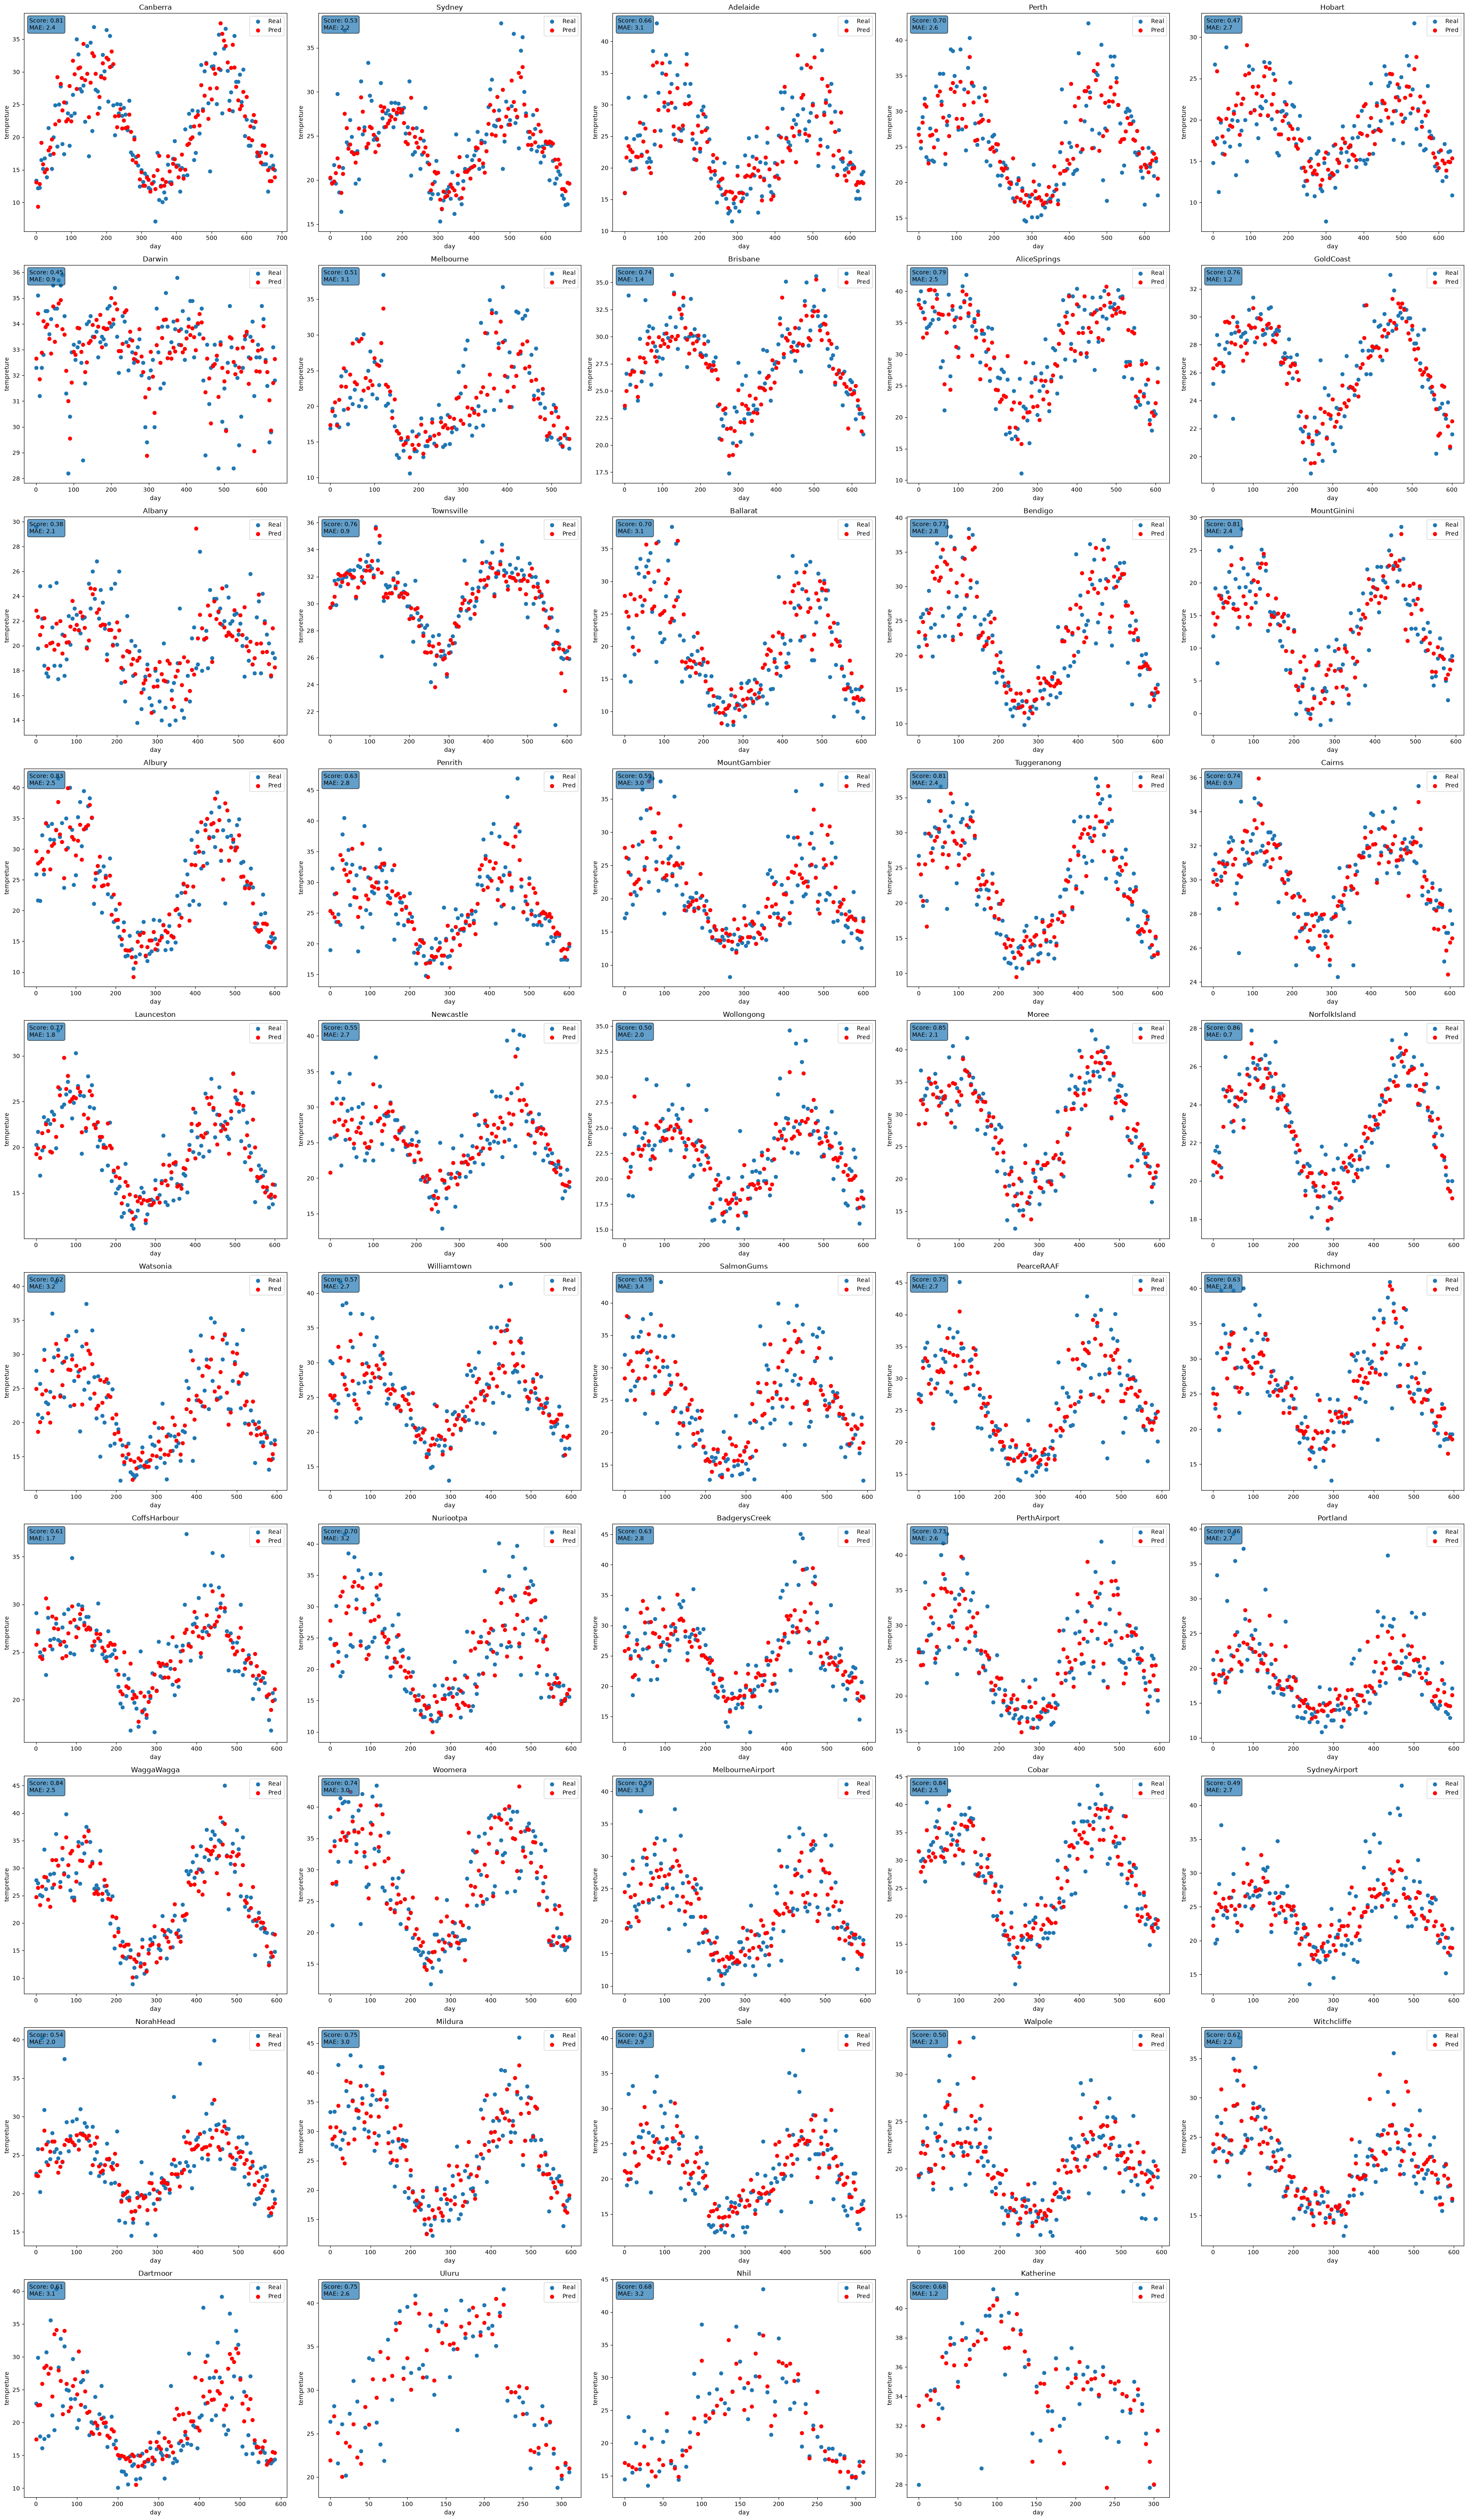

In [66]:
plt.figure(figsize=(35, 60))

for i in range(len(city)):
    
    model, stats, splited = train_cities(city[i])
    plt.subplot(10, 5, i+1)

    
    # try:
    r =  np.arange(len(splited['xtest']))
    plt.scatter(r[:: 5], splited['ytest'][:: 5])
    plt.scatter(r[:: 5], stats['pred'][:: 5], c='r')

    # except Exception as e:
    #     print(r.shape, ytest.shape, e)
    #     break
    
    plt.title(city[i][0])
    plt.text(
        0.02, 0.98,
        f"Score: {stats['score_test']:.2f}\nMAE: {stats['mae']:.1f}",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', alpha=0.7)
    )
    plt.xlabel('day')
    plt.ylabel('tempreture')
    plt.legend(['Real', 'Pred'])

plt.tight_layout()

In [ ]:
model = LinearRegression()

In [ ]:
d = city[0]

In [ ]:
xtrain, xtest, ytrain, ytest = split([city[0]])
model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.06, 0.04, 0.07,..., 0.08,-0.09, 0.74]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['d1','d2','d3',...,'d5','d6','d7']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.115
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [ ]:
model.score(xtrain, ytrain)

0.8039197903867682

In [ ]:
model.score(xtest, ytest)

0.809565871278034

In [ ]:
p = model.predict(xtest)

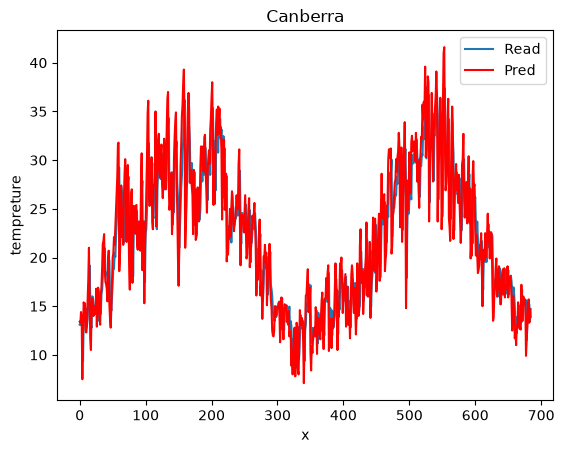

In [ ]:
ax0 = range(len(xtest))
plt.plot(ax0, p)
plt.plot(ax0, ytest, c='r')
plt.title(city[0][0])
plt.xlabel('x')
plt.ylabel('tempreture')
plt.legend(['Read', 'Pred'])